# Plume interannual variability snapshots

four weeks before, snapshots of model and SST/SSS to show plume interannual variability in regional extent
7 rows, one for each year
2 columns, SSS and SIC overlaid for model and obs

In [1]:
## import required packages
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
from pyproj import Proj, Transformer
import glob
import os
import string
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import boto3
import s3fs
import re
import calendar

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:40853")
client

<Client: 'tcp://127.0.0.1:40853' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# manually specify when ice bridges were observed
ice_bridge_dates = ['20151023', '20161021', '20171030', '20180913', '20191025', '20201016']

In [4]:
def generate_4wks_b4_dates(dates):
    """
    Given a list of dates in 'YYYYMMDD' format, return a dictionary mapping each date
    to a list of dates [4 weeks before].
    """
    result = []
    for date_str in dates:
        base_date = datetime.strptime(date_str, '%Y%m%d')
        date_list = [
            (base_date - timedelta(weeks=4)).strftime('%Y%m%d')
        ]
        result.append(date_list)
    return result

In [5]:
def convert_to_doy_strings(dates):
    """
    Convert a list of date strings (YYYYMMDD) to 'YYYY_DDD' format where DDD is day of year.
    """
    doy_strings = []
    for date_str in dates:
        dt = datetime.strptime(date_str, '%Y%m%d')
        doy = dt.timetuple().tm_yday
        doy_strings.append(f"{dt.year}_{doy:03d}")
    return doy_strings

In [6]:
# check
b4_bridge_dates = generate_4wks_b4_dates(ice_bridge_dates)
print(b4_bridge_dates)

[['20150925'], ['20160923'], ['20171002'], ['20180816'], ['20190927'], ['20200918']]


In [7]:
# manual
# b4_bridge_dates = [['20150901'], ['20160901'], ['20170901'], ['20180901'], ['20190901'], ['20200901']]

In [8]:
sic_file_paths = []
sss_file_paths = []

for date in b4_bridge_dates:

    print("Date:", date)
    print("---")
    
    # Set data directory and load all matching NetCDF files
    sic_dir = "/home/jpluser/efs-mount-point/mzahn/satellite_data/sic_nsidc_cdr"
    sic_file_paths.append(sorted(glob.glob(os.path.join(sic_dir, f"*{date[0]}*.nc"))))

    # SSS is in DOY format so need to convert the date first
    doy_date = convert_to_doy_strings(date)
    sss_dir = "/home/jpluser/efs-mount-point/mzahn/satellite_data/sss_rss_smap"
    sss_file_paths.append(sorted(glob.glob(os.path.join(sss_dir, f"*{doy_date[0]}*.nc"))))

Date: ['20150925']
---
Date: ['20160923']
---
Date: ['20171002']
---
Date: ['20180816']
---
Date: ['20190927']
---
Date: ['20200918']
---


In [9]:
sic_file_paths

[['/home/jpluser/efs-mount-point/mzahn/satellite_data/sic_nsidc_cdr/sic_psn25_20150925_F17_v05r00.nc'],
 ['/home/jpluser/efs-mount-point/mzahn/satellite_data/sic_nsidc_cdr/sic_psn25_20160923_F17_v05r00.nc'],
 ['/home/jpluser/efs-mount-point/mzahn/satellite_data/sic_nsidc_cdr/sic_psn25_20171002_F17_v05r00.nc'],
 ['/home/jpluser/efs-mount-point/mzahn/satellite_data/sic_nsidc_cdr/sic_psn25_20180816_F17_v05r00.nc'],
 ['/home/jpluser/efs-mount-point/mzahn/satellite_data/sic_nsidc_cdr/sic_psn25_20190927_F17_v05r00.nc'],
 ['/home/jpluser/efs-mount-point/mzahn/satellite_data/sic_nsidc_cdr/sic_psn25_20200918_F17_v05r00.nc']]

In [10]:
sss_file_paths

[['/home/jpluser/efs-mount-point/mzahn/satellite_data/sss_rss_smap/RSS_smap_SSS_L3_8day_running_2015_268_FNL_v06.0.nc'],
 ['/home/jpluser/efs-mount-point/mzahn/satellite_data/sss_rss_smap/RSS_smap_SSS_L3_8day_running_2016_267_FNL_v06.0.nc'],
 ['/home/jpluser/efs-mount-point/mzahn/satellite_data/sss_rss_smap/RSS_smap_SSS_L3_8day_running_2017_275_FNL_v06.0.nc'],
 ['/home/jpluser/efs-mount-point/mzahn/satellite_data/sss_rss_smap/RSS_smap_SSS_L3_8day_running_2018_228_FNL_v06.0.nc'],
 ['/home/jpluser/efs-mount-point/mzahn/satellite_data/sss_rss_smap/RSS_smap_SSS_L3_8day_running_2019_270_FNL_v06.0.nc'],
 ['/home/jpluser/efs-mount-point/mzahn/satellite_data/sss_rss_smap/RSS_smap_SSS_L3_8day_running_2020_262_FNL_v06.0.nc']]

### Open model data

In [11]:
def get_aws_credentials(profile_name='sassie'):
    session = boto3.Session(profile_name=profile_name)
    credentials = session.get_credentials()
    return credentials

In [12]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, aws_credentials):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(anon=False, key=aws_credentials.access_key, secret=aws_credentials.secret_key)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

In [17]:
# get creds
aws_credentials = get_aws_credentials(profile_name='sassie_read')

In [18]:
# open SIarea zarr store - [fraction of sea ice, 0 to 1]
sic_model_ds = open_zarr_store('s3://podaac-dev-sassie/ECCO_model/N1/V1R1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', aws_credentials)
salt_model_ds = open_zarr_store('s3://podaac-dev-sassie/ECCO_model/N1/V1R1/HH/ZARR/SALT_AVG_DAILY.ZARR/', aws_credentials)

In [19]:
# select beaufort sea box and reduce domain size
sic_beaufort_da = (sic_model_ds.SIarea*100).isel(i=slice(510,850),j=slice(0,500))
salt_beaufort_da = salt_model_ds.SALT.isel(k=0,i=slice(510,850),j=slice(0,500))

#### Create custom colormap for sea ice

In [20]:
def remap_colormap(cmap, nonlin_scale=np.sqrt, n=256):
    """
    Remap a colormap so that lower values are compressed (darker colors take up less space),
    and higher values (lighter colors) are stretched out.
    
    Parameters:
    - cmap: The original colormap (e.g., cmocean.cm.ice)
    - nonlin_scale: A function that maps [0,1] -> [0,1] nonlinearly (default: np.sqrt)
    - n: Number of color levels
    
    Returns:
    - A new colormap with redistributed colors.
    """
    # Generate linearly spaced values, then apply non-linear scaling
    orig_vals = np.linspace(0, 1, n)
    remapped_vals = nonlin_scale(orig_vals)

    # Normalize remapped values to stay in [0,1]
    remapped_vals = (remapped_vals - remapped_vals.min()) / (remapped_vals.max() - remapped_vals.min())

    # Map those values through the original colormap
    new_colors = cmap(remapped_vals)
    
    return LinearSegmentedColormap.from_list(f'remapped_{cmap.name}', new_colors, N=n)

In [21]:
from matplotlib.colors import LinearSegmentedColormap

# create a nonlinearly adjusted colormap from the cmocean ice colormap
custom_ice_cmap = remap_colormap(cmocean.cm.ice, nonlin_scale=np.sqrt)  # sqrt compresses low end

## Plot snapshot from 4 weeks before ice bridge

In [28]:
# flatten list
sic_file_paths = [f[0] for f in sic_file_paths]
# open all files
sat_sic_ds = xr.open_mfdataset(sic_file_paths)

# flatten list
sss_file_paths = [f[0] for f in sss_file_paths]
# open all files
sat_sss_ds = xr.open_mfdataset(sss_file_paths)

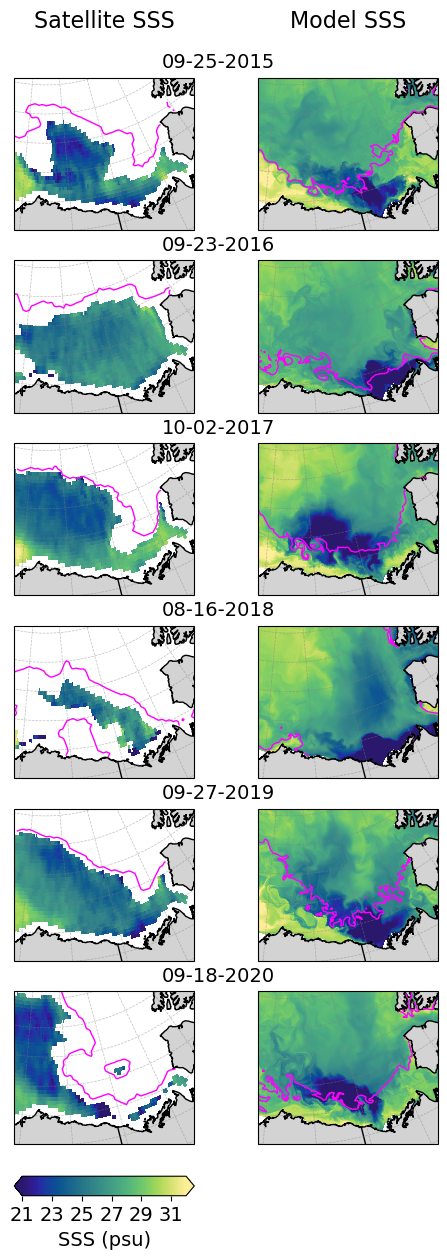

In [34]:
plt.rcParams['font.size'] = 14

# Define NSIDC stereographic projection
nsidc_proj = Proj(proj='stere', lat_0=90, lon_0=-45, lat_ts=70,
                  a=6378273, b=6356889.449, units='m')
transformer = Transformer.from_proj(nsidc_proj, "epsg:4326", always_xy=True)

# Create 6x2 layout
fig, axes = plt.subplots(6, 2, figsize=(6, 13),
                         subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-155)})
plt.subplots_adjust(wspace=0.1, hspace=0.2, right=0.9, top=0.93)
axes = axes.reshape(6, 2)

# --- COLUMN TITLES -----------------------------------------------------------
col0_pos = axes[0,0].get_position()
col1_pos = axes[0,1].get_position()

fig.text((col0_pos.x0 + col0_pos.x1)/2, 0.965,
         "Satellite SSS", ha='center', va='bottom', fontsize=16)

fig.text((col1_pos.x0 + col1_pos.x1)/2, 0.965,
         "Model SSS", ha='center', va='bottom', fontsize=16)
# ------------------------------------------------------------------------------

labels = list(string.ascii_lowercase)
pcolormesh_handle = None
sss_im_list = []

for i in range(len(sat_sic_ds.time)):
    # Load SIC and convert
    sic_ds = sat_sic_ds.isel(time=i)
    sic = sic_ds['cdr_seaice_conc'].squeeze()
    if sic.max() > 1.5:
        sic = sic / 100.0
    sic_masked = np.where(sic > 0.15, sic, np.nan)

    # Load SSS
    sss = sat_sss_ds.isel(time=i).sss_smap.squeeze()

    # Lat/lon
    x = sic_ds['x'].values
    y = sic_ds['y'].values
    X, Y = np.meshgrid(x, y)
    lon, lat = transformer.transform(X, Y)

    # --- ROW TITLE ------------------------------------------------------------
    dt = pd.to_datetime(sic_ds['time'].values)
    date_title = dt.strftime('%m-%d-%Y')

    # Compute vertical position above this row
    row_top_y = max(axes[i,0].get_position().y1, axes[i,1].get_position().y1)

    # Place row title centered between columns
    fig.text(0.5, row_top_y + 0.008, date_title,
             ha='center', fontsize=14)
    # ---------------------------------------------------------------------------

    for j in range(2):
        ax = axes[i, j]
        ax.set_extent([-161, -126, 69, 78], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m', facecolor='lightgray'))
        ax.add_feature(cfeature.BORDERS.with_scale('10m'))
        ax.add_feature(cfeature.COASTLINE.with_scale('10m'))
        gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray',
                          alpha=0.5, linestyle='--', ylocs=[67, 69, 71, 73, 75, 77, 79])

        # --- SATELLITE COLUMN (LEFT) -----------------------------------------
        if j == 0:
            sss_cb = sss.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmocean.cm.haline,
                              vmin=21, vmax=32, add_colorbar=False, extend='both')

            # sic_cb = ax.pcolormesh(lon, lat, sic_masked * 100, transform=ccrs.PlateCarree(),
            #                        cmap=custom_ice_cmap, shading='auto', vmin=0, vmax=100)

            # 15% contour
            regional_mask = ((lon >= -165) & (lon <= -120) & (lat >= 66) & (lat <= 80))
            sic_region = np.where(regional_mask, sic, np.nan)
            ax.contour(lon, lat, sic_region * 100, levels=[15], colors='magenta',
                       linewidths=1, transform=ccrs.PlateCarree())
            
            ax.set_title("")
            
        # --- MODEL COLUMN (RIGHT) --------------------------------------------
        else:
            date = sss.time.values
            sss_model = salt_beaufort_da.sel(time=str(date))
            sic_model = sic_beaufort_da.sel(time=str(date))

            # # check dates
            # print(sic.time.values)
            # print(sss.time.values)
            # print(sic_model.time.values)
            # print(sss_model.time.values)

            sic_model_filter = sic_model.where(sic_model > 15)

            sss_cb = ax.pcolormesh(sss_model.XC, sss_model.YC, sss_model.values,
                                   transform=ccrs.PlateCarree(), cmap=cmocean.cm.haline,
                                   vmin=21, vmax=32)
            ax.contour(sic_model.XC, sic_model.YC, sic_model.values, levels=[15], colors='magenta',
                       linewidths=1, transform=ccrs.PlateCarree())

            ax.set_title("")

# --- SATELLITE SSS COLORBAR at bottom of left column ----------------------
left_col_axes = axes[:, 0]
bottom = left_col_axes[-1].get_position().y0
left = left_col_axes[0].get_position().x0
width = left_col_axes[0].get_position().width

cbar_ax = fig.add_axes([left, bottom - 0.04, width, 0.015])  # x0, y0, w, h
cbar = fig.colorbar(sss_cb, cax=cbar_ax, orientation='horizontal', extend='both')
cbar.set_label("SSS (psu)")
cbar.set_ticks([21, 23, 25, 27, 29, 31])

## Plot August and September averages

In [22]:
def get_files_by_year_month(file_list, year, month):
    """
    Returns a list of files corresponding to a given year and month
    based on filenames with pattern: *_YYYY_DDD_*.nc

    Parameters
    ----------
    file_list : list of str
        List of filenames
    year : int
        Year to filter (e.g., 2017)
    month : int
        Month to filter (1=Jan, 12=Dec)

    Returns
    -------
    filtered_files : list of str
        List of filenames matching the year and month
    """

    # Compute first and last day of the month
    first_day = datetime(year, month, 1)
    last_day = datetime(year, month, calendar.monthrange(year, month)[1])

    # Convert to DOY
    first_doy = first_day.timetuple().tm_yday
    last_doy = last_day.timetuple().tm_yday

    filtered_files = []
    for f in file_list:
        m = re.search(r'_(\d{4})_(\d{3})_', f)
        if m:
            file_year = int(m.group(1))
            file_doy = int(m.group(2))
            if file_year == year and first_doy <= file_doy <= last_doy:
                filtered_files.append(f)

    return filtered_files

In [23]:
sic_dir = "/home/jpluser/efs-mount-point/mzahn/satellite_data/sic_nsidc_cdr"
sat_sic_file_paths = sorted(glob.glob(os.path.join(sic_dir, "*.nc")))

sss_dir = "/home/jpluser/efs-mount-point/mzahn/satellite_data/sss_rss_smap"
sat_sss_file_paths = sorted(glob.glob(os.path.join(sss_dir, "*.nc")))

In [24]:
# Get all August 2017 Sat SSS files
aug2017_files = get_files_by_year_month(sat_sss_file_paths, 2017, 8)

# Get all September Sat SSS 2017 files
sept2017_files = get_files_by_year_month(sat_sss_file_paths, 2017, 9)

In [25]:
# flatten list
sic_file_paths = [f[0] for f in sic_file_paths]
# open all files
sat_sic_ds = xr.open_mfdataset(sic_file_paths)

# flatten list
sss_file_paths = [f[0] for f in sss_file_paths]
# open all files
sat_sss_ds = xr.open_mfdataset(sss_file_paths)

In [35]:
# calculate monthly average for model datasets
month = 9
salt_beaufort_month_da = salt_beaufort_da.sel(time=salt_beaufort_da['time.month'] == month).sel(time=slice('2015','2020'))
sic_beaufort_month_da = sic_beaufort_da.sel(time=sic_beaufort_da['time.month'] == month).sel(time=slice('2015','2020'))

# group by year and take the mean over time
salt_month_mean = salt_beaufort_month_da.groupby('time.year').mean(dim='time').load()
sic_month_mean = sic_beaufort_month_da.groupby('time.year').mean(dim='time').load()

KeyError: "No variable named 'cdr_seaice_conc'. Did you mean one of ('sea_ice_zones',)?"

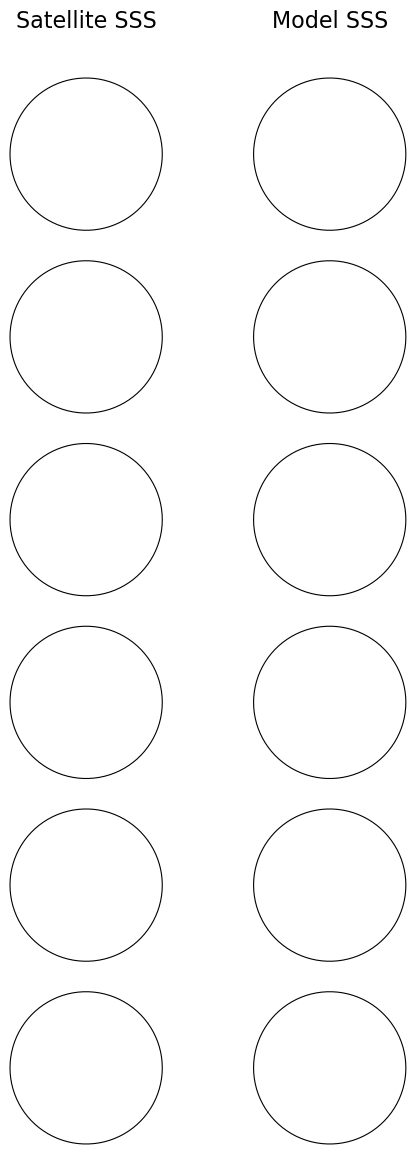

In [50]:
plt.rcParams['font.size'] = 14

# Define NSIDC stereographic projection
nsidc_proj = Proj(proj='stere', lat_0=90, lon_0=-45, lat_ts=70,
                  a=6378273, b=6356889.449, units='m')
transformer = Transformer.from_proj(nsidc_proj, "epsg:4326", always_xy=True)

# Create 6x2 layout
fig, axes = plt.subplots(6, 2, figsize=(6, 13),
                         subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-155)})
plt.subplots_adjust(wspace=0.1, hspace=0.2, right=0.9, top=0.93)
axes = axes.reshape(6, 2)

# --- COLUMN TITLES -----------------------------------------------------------
col0_pos = axes[0,0].get_position()
col1_pos = axes[0,1].get_position()

fig.text((col0_pos.x0 + col0_pos.x1)/2, 0.965,
         "Satellite SSS", ha='center', va='bottom', fontsize=16)

fig.text((col1_pos.x0 + col1_pos.x1)/2, 0.965,
         "Model SSS", ha='center', va='bottom', fontsize=16)
# ------------------------------------------------------------------------------

labels = list(string.ascii_lowercase)
pcolormesh_handle = None
sss_im_list = []

years = np.arange(2015,2021,1)

for i in range(len(years)):

    # Get all September Sat files by year
    month_sss_files = get_files_by_year_month(sat_sss_file_paths, years[i], 9)
    month_sic_files = sorted(glob.glob(os.path.join(sic_dir, f"*{years[i]}09*.nc")))

    # open all files
    sat_sic_ds = xr.open_mfdataset(month_sss_files)
    sat_sss_ds = xr.open_mfdataset(month_sic_files)

    # take monthly mean
    sat_sic_month_avg = sat_sic_ds['cdr_seaice_conc'].mean('time')
    sat_sss_month_avg = sat_sss_ds['sss_smap'].mean('time')
    
    # Load SIC and convert
    sic = sat_sic_month_avg.squeeze()
    if sic.max() > 1.5:
        sic = sic / 100.0

    # Load SSS
    sss = sat_sss_month_avg.squeeze()

    # Lat/lon
    x = sic_ds['x'].values
    y = sic_ds['y'].values
    X, Y = np.meshgrid(x, y)
    lon, lat = transformer.transform(X, Y)

    # --- ROW TITLE ------------------------------------------------------------
    dt = pd.to_datetime(sic_ds['time'].values)
    date_title = dt.strftime('%m-%Y')

    # Compute vertical position above this row
    row_top_y = max(axes[i,0].get_position().y1, axes[i,1].get_position().y1)

    # Place row title centered between columns
    fig.text(0.5, row_top_y + 0.008, date_title,
             ha='center', fontsize=14)
    # ---------------------------------------------------------------------------

    for j in range(2):
        ax = axes[i, j]
        ax.set_extent([-161, -126, 69, 78], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m', facecolor='lightgray'))
        ax.add_feature(cfeature.BORDERS.with_scale('10m'))
        ax.add_feature(cfeature.COASTLINE.with_scale('10m'))
        gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray',
                          alpha=0.5, linestyle='--', ylocs=[67, 69, 71, 73, 75, 77, 79])

        # --- SATELLITE COLUMN (LEFT) -----------------------------------------
        if j == 0:
            sss_cb = sss.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmocean.cm.haline,
                              vmin=21, vmax=32, add_colorbar=False, extend='both')

            # sic_cb = ax.pcolormesh(lon, lat, sic_masked * 100, transform=ccrs.PlateCarree(),
            #                        cmap=custom_ice_cmap, shading='auto', vmin=0, vmax=100)

            # 15% contour
            regional_mask = ((lon >= -165) & (lon <= -120) & (lat >= 66) & (lat <= 80))
            sic_region = np.where(regional_mask, sic, np.nan)
            ax.contour(lon, lat, sic_region * 100, levels=[15], colors='magenta',
                       linewidths=1, transform=ccrs.PlateCarree())
            
            ax.set_title("")
            
        # --- MODEL COLUMN (RIGHT) --------------------------------------------
        else:
            sss_model = salt_month_mean.isel(year=i)
            sic_model = sic_month_mean.isel(year=i)
            # print(sss_model.year.values)
            sss_cb = ax.pcolormesh(sss_model.XC, sss_model.YC, sss_model.values,
                                   transform=ccrs.PlateCarree(), cmap=cmocean.cm.haline,
                                   vmin=21, vmax=32)
            ax.contour(sic_model.XC, sic_model.YC, sic_model.values, levels=[15], colors='magenta',
                       linewidths=1, transform=ccrs.PlateCarree())

            ax.set_title("")

# --- SATELLITE SSS COLORBAR at bottom of left column ----------------------
left_col_axes = axes[:, 0]
bottom = left_col_axes[-1].get_position().y0
left = left_col_axes[0].get_position().x0
width = left_col_axes[0].get_position().width

cbar_ax = fig.add_axes([left, bottom - 0.04, width, 0.015])  # x0, y0, w, h
cbar = fig.colorbar(sss_cb, cax=cbar_ax, orientation='horizontal', extend='both')
cbar.set_label("SSS (psu)")
cbar.set_ticks([21, 23, 25, 27, 29, 31])